# Goal:

So far, we have always been using a least squares cost function defined as

$$f(A, K, B) := \sum_{j \in \text{POVM}} \sum_{i \in \text{Sequences}} \left(p_{i,j}(A, K, B) - y_{i,j} \right)^2 $$


Instead, a well theoretically-motivated cost function is the log-likelihood function

$$\log L(A, K, B) := \sum_{j \in \text{POVM}} \sum_{i \in \text{Sequences}} y_{i,j} \log [p_{i,j}(A, K, B)] $$

The goal of this notebook is to

0. Implement the log-likelihood function. ✅
1. Test the values agree with roughly the square root of the least squares and the ones from MGST ✅
2. Test gradient computes and time against least squares ✅
2. Perform optimization with it ☑️

In [47]:
import jax.numpy as jnp

from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration
from mGST.utility_functions_comparisons import all_operators_from_configuration, kraus_tensor_to_mgst, get_compressed_rep_from_mgst_output, get_compressed_perturbed_kraus_from_superop, get_compressed_perturbed_rep_from_mgst, get_mgst_tensors_from_psd_representation
from mGST.simulate import generate_sequence_indices, compute_probability_matrices
from mGST.low_level_jit import cost_function_jax_mps, objf
from mGST.automatic_diff import automatic_gradient
from mGST.typing import OperatorSchedule, TrustRegionOptions
from mGST.simulate import run_optimization_workflow
from mGST.analysis import mve_avg_and_std_from_list_of_superops
from mGST.visualization import plot_cost_function, plot_mve_multiple_seq_lengths_with_error_bars, plot_mve_multiple_seq_lengths

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Get the tensors to test the cost function with

In [2]:
shots = 1000
num_sequences = 100
backend = "iqmfakeapollo" # just to create the benchmark and then get the gate set

In [3]:
Minimal_1Q_GST = GSTConfiguration(
    qubit_layouts=[[0]],
    gate_set="1QXYI",
    num_circuits=num_sequences,
    shots=shots,
    rank=4,
    verbose_level=2,
    convergence_criteria =  [3, 1e-20],
    max_iterations = [0,40],
    opt_method = "SFN",
    from_init = True,
    )

target_operators = all_operators_from_configuration(Minimal_1Q_GST, backend)
print(target_operators.keys())

# now get the superoperator for Kraus
povm_vect_target = target_operators["povm"]
state_vect_target = target_operators["state"]
kraus_tensor_unitary_target = target_operators["kraus"]
kraus_superop_target = kraus_tensor_to_mgst(kraus_tensor_unitary_target)

INFO:2026-07-16 16:03:04,601:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-07-16 16:03:04,601 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-07-16 16:03:04,605:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/

dict_keys(['kraus', 'povm', 'state', 'gate_labels'])


In [4]:
num_qubits = 1
dim = 2**num_qubits
kraus_rank = dim**2
povm_rank = dim
state_rank = dim
num_gates = 3
num_shots = 1000

# Initial tensors

In [5]:
kraus_tensor_target, povm_psd_target, state_psd_target = get_compressed_rep_from_mgst_output(kraus_superop_target, povm_vect_target, state_vect_target, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

target_psd_operators = {
    "kraus": kraus_tensor_target,
    "povm": povm_psd_target,
    "state": state_psd_target
}
print("Target operators PSD:", [op.shape for op in target_psd_operators.values()])

kraus_tensor_init_dict = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=kraus_rank, seed=42)
kraus_tensor_init = kraus_tensor_init_dict["kraus_tensor"]

povm_psd_init, state_psd_init = get_compressed_perturbed_rep_from_mgst(povm_vect_target, state_vect_target, rank_povm=povm_rank, rank_state=state_rank)

init_operators = {
    "kraus": kraus_tensor_init,
    "povm": povm_psd_init,
    "state": state_psd_init,
}

true_superops={
    "kraus": kraus_superop_target,
    "povm": povm_vect_target,
    "state": state_vect_target
}

print(f"Init operators PSD: {[v.shape for v in init_operators.values()]}")
print(f"Target superops: {[v.shape for v in true_superops.values()]}")

Target operators PSD: [(3, 4, 2, 2), (2, 2, 2), (2, 2)]
Init operators PSD: [(3, 4, 2, 2), (2, 2, 2), (2, 2)]
Target superops: [(3, 4, 4), (2, 4), (4,)]


In [6]:
# get the MGST representation from the perturbed init operators
init_superops = get_mgst_tensors_from_psd_representation(*init_operators.values())
init_superops.keys()

dict_keys(['kraus', 'povm', 'state'])

In [7]:
seq_len_list = [1, 8, 14]
indices_dict = generate_sequence_indices(num_gates=num_gates, num_circuits=num_sequences, seq_len_list=seq_len_list)
indices_list = indices_dict["gate_indices"]
indices_list_mgst = indices_dict["gate_indices_with_negs"]

probability_matrices = compute_probability_matrices(*target_psd_operators.values(), gate_indices=indices_list, num_shots=num_shots, seed=42)
probability_matrix = probability_matrices["sampled"]

In [34]:
probability_matrix_exact = probability_matrices["exact"]

In [12]:
cost_fn_kwargs_jax = {
    "indices_list": indices_list,
    "prob_matrix": probability_matrix,
    "jit": True,
}

cost_fn_kwargs_mgst = {
    "J": indices_list_mgst,
    "y": probability_matrix,
}

# Least squares test

In [14]:
cost_jax_least_squares = cost_function_jax_mps(*init_operators.values(), **cost_fn_kwargs_jax)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 4 the new count changed to: 3
at iteration 10 the new count changed to: 4
at iteration 16 the new count changed to: 5
at iteration 22 the new count changed to: 6
at iteration 29 the new count changed to: 7
at iteration 36 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iteration 82 the new count changed to: 14
at iteration 91 the new count changed to: 15


In [15]:
cost_jax_least_squares

Array(0.00116301, dtype=float64)

In [16]:
cost_mgst_least_squares = objf(*init_superops.values(), **cost_fn_kwargs_mgst)
cost_mgst_least_squares

0.0011630097602877863

In [17]:
jnp.allclose(cost_jax_least_squares, cost_mgst_least_squares)

Array(True, dtype=bool)

## Log-likelihood function

In [18]:
cost_jax_log_likelihood = cost_function_jax_mps(*init_operators.values(), **cost_fn_kwargs_jax, use_log_likelihood=True, num_shots=num_shots)
cost_jax_log_likelihood

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 4 the new count changed to: 3
at iteration 10 the new count changed to: 4
at iteration 16 the new count changed to: 5
at iteration 22 the new count changed to: 6
at iteration 29 the new count changed to: 7
at iteration 36 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iteration 82 the new count changed to: 14
at iteration 91 the new count changed to: 15


Array(43.58881594, dtype=float64)

In [19]:
cost_mgst_log_likelihood = objf(*init_superops.values(), **cost_fn_kwargs_mgst, mle=True)
cost_mgst_log_likelihood

43.588815940353136

# Gradient & timing

In [ ]:
cost_fn_x_least_squares = lambda x: cost_function_jax_mps(
                kraus_tensor=x, povm_psd=povm_psd_init, state_psd=state_psd_init, **cost_fn_kwargs_jax)

cost_fn_x_log_likelihood = lambda x: cost_function_jax_mps(
                kraus_tensor=x, povm_psd=povm_psd_init, state_psd=state_psd_init, **cost_fn_kwargs_jax, use_log_likelihood=True, num_shots=num_shots)

gradient_fn_least_squares = automatic_gradient(cost_fn_x_least_squares)
gradient_fn_log_likelihood = automatic_gradient(cost_fn_x_log_likelihood)

In [22]:
timing_cost_least_squares = %timeit -o cost_fn_x_least_squares(kraus_tensor_init)
timing_cost_log_likelihood = %timeit -o cost_fn_x_log_likelihood(kraus_tensor_init)

2.74 ms ± 68.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.73 ms ± 39.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [23]:
timing_grad_least_squares = %timeit -o gradient_fn_least_squares(kraus_tensor_init)
timing_grad_log_likelihood = %timeit -o gradient_fn_log_likelihood(kraus_tensor_init)

124 ms ± 2.24 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
127 ms ± 2.49 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Optimization

In [25]:
num_iterations_outer = 20
num_iterations_tr = 5
num_iterations_cg = 10 
tol_grad = 1e-8 # it was 1e-4 before. 1e-8 is suggested in the book.

tr_schedule_verbose = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad))

relative_precision = 1e-13 #
global_grad_norm_tol = 1e-10 #

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}

optimization_options = {
    "schedule": optimization_schedule_all_tr,
    "num_iterations_outer": num_iterations_outer,
    "relative_precision": relative_precision,
    "global_gradient_norm_tol": global_grad_norm_tol
}
optimization_options

{'schedule': {'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
  'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
  'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))])},
 'num_iterations_outer': 20,
 'relative_precision': 1e-13,
 'global_gradient_norm_tol': 1e-10}

In [ ]:
optimization_results_100_seq_exact_log_likelihood = run_optimization_workflow(
    num_sequences=num_sequences,
    num_shots=1, # since we are using the exact probabilities.
    init_operators=init_operators,
    operators_psd_true=target_psd_operators,
    target_superops=true_superops,
    use_exact_probabilities=True,
    optimization_options=optimization_options,
    warmup_run=True,
    use_log_likelihood=True,
)

Using exact probabilities 🔪
Using log-likelihood for the cost function optimization 🧮
🏎️ Warming up the cost function ...
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 4 the new count changed to: 3
at iteration 10 the new count changed to: 4
at iteration 16 the new count changed to: 5
at iteration 22 the new count changed to: 6
at iteration 29 the new count changed to: 7
at iteration 36 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iteration 82 the new count changed to: 14
at iteration 91 the new count changed to: 15
Initial cost value: 44212.32870940714
🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-19]: TrustRegionOptions
povm: Schedule:
  [0-19]: TrustRegionOptions
state: Schedule:
  [0

In [87]:
a = {"emiliano": "goat"}
a.pop("emiliano")
print()

In [35]:
cost_fn_kwargs_jax_exact = {
    "indices_list": indices_list,
    "prob_matrix": probability_matrix_exact,
    "jit": True,
}

In [36]:
# what is the least squares value with these optimized parameters
optimized_ops = optimization_results_100_seq_exact_log_likelihood["optimized_operators"]
optimized_cost_least_squares = cost_function_jax_mps(*optimized_ops.values(), **cost_fn_kwargs_jax_exact)
optimized_cost_least_squares

at iteration 0 the new count changed to: 16
at iteration 1 the new count changed to: 17
at iteration 4 the new count changed to: 18
at iteration 10 the new count changed to: 19
at iteration 16 the new count changed to: 20
at iteration 22 the new count changed to: 21
at iteration 29 the new count changed to: 22
at iteration 36 the new count changed to: 23
at iteration 43 the new count changed to: 24
at iteration 50 the new count changed to: 25
at iteration 58 the new count changed to: 26
at iteration 66 the new count changed to: 27
at iteration 74 the new count changed to: 28
at iteration 82 the new count changed to: 29
at iteration 91 the new count changed to: 30


Array(5.71718873e-15, dtype=float64)

# Analysis

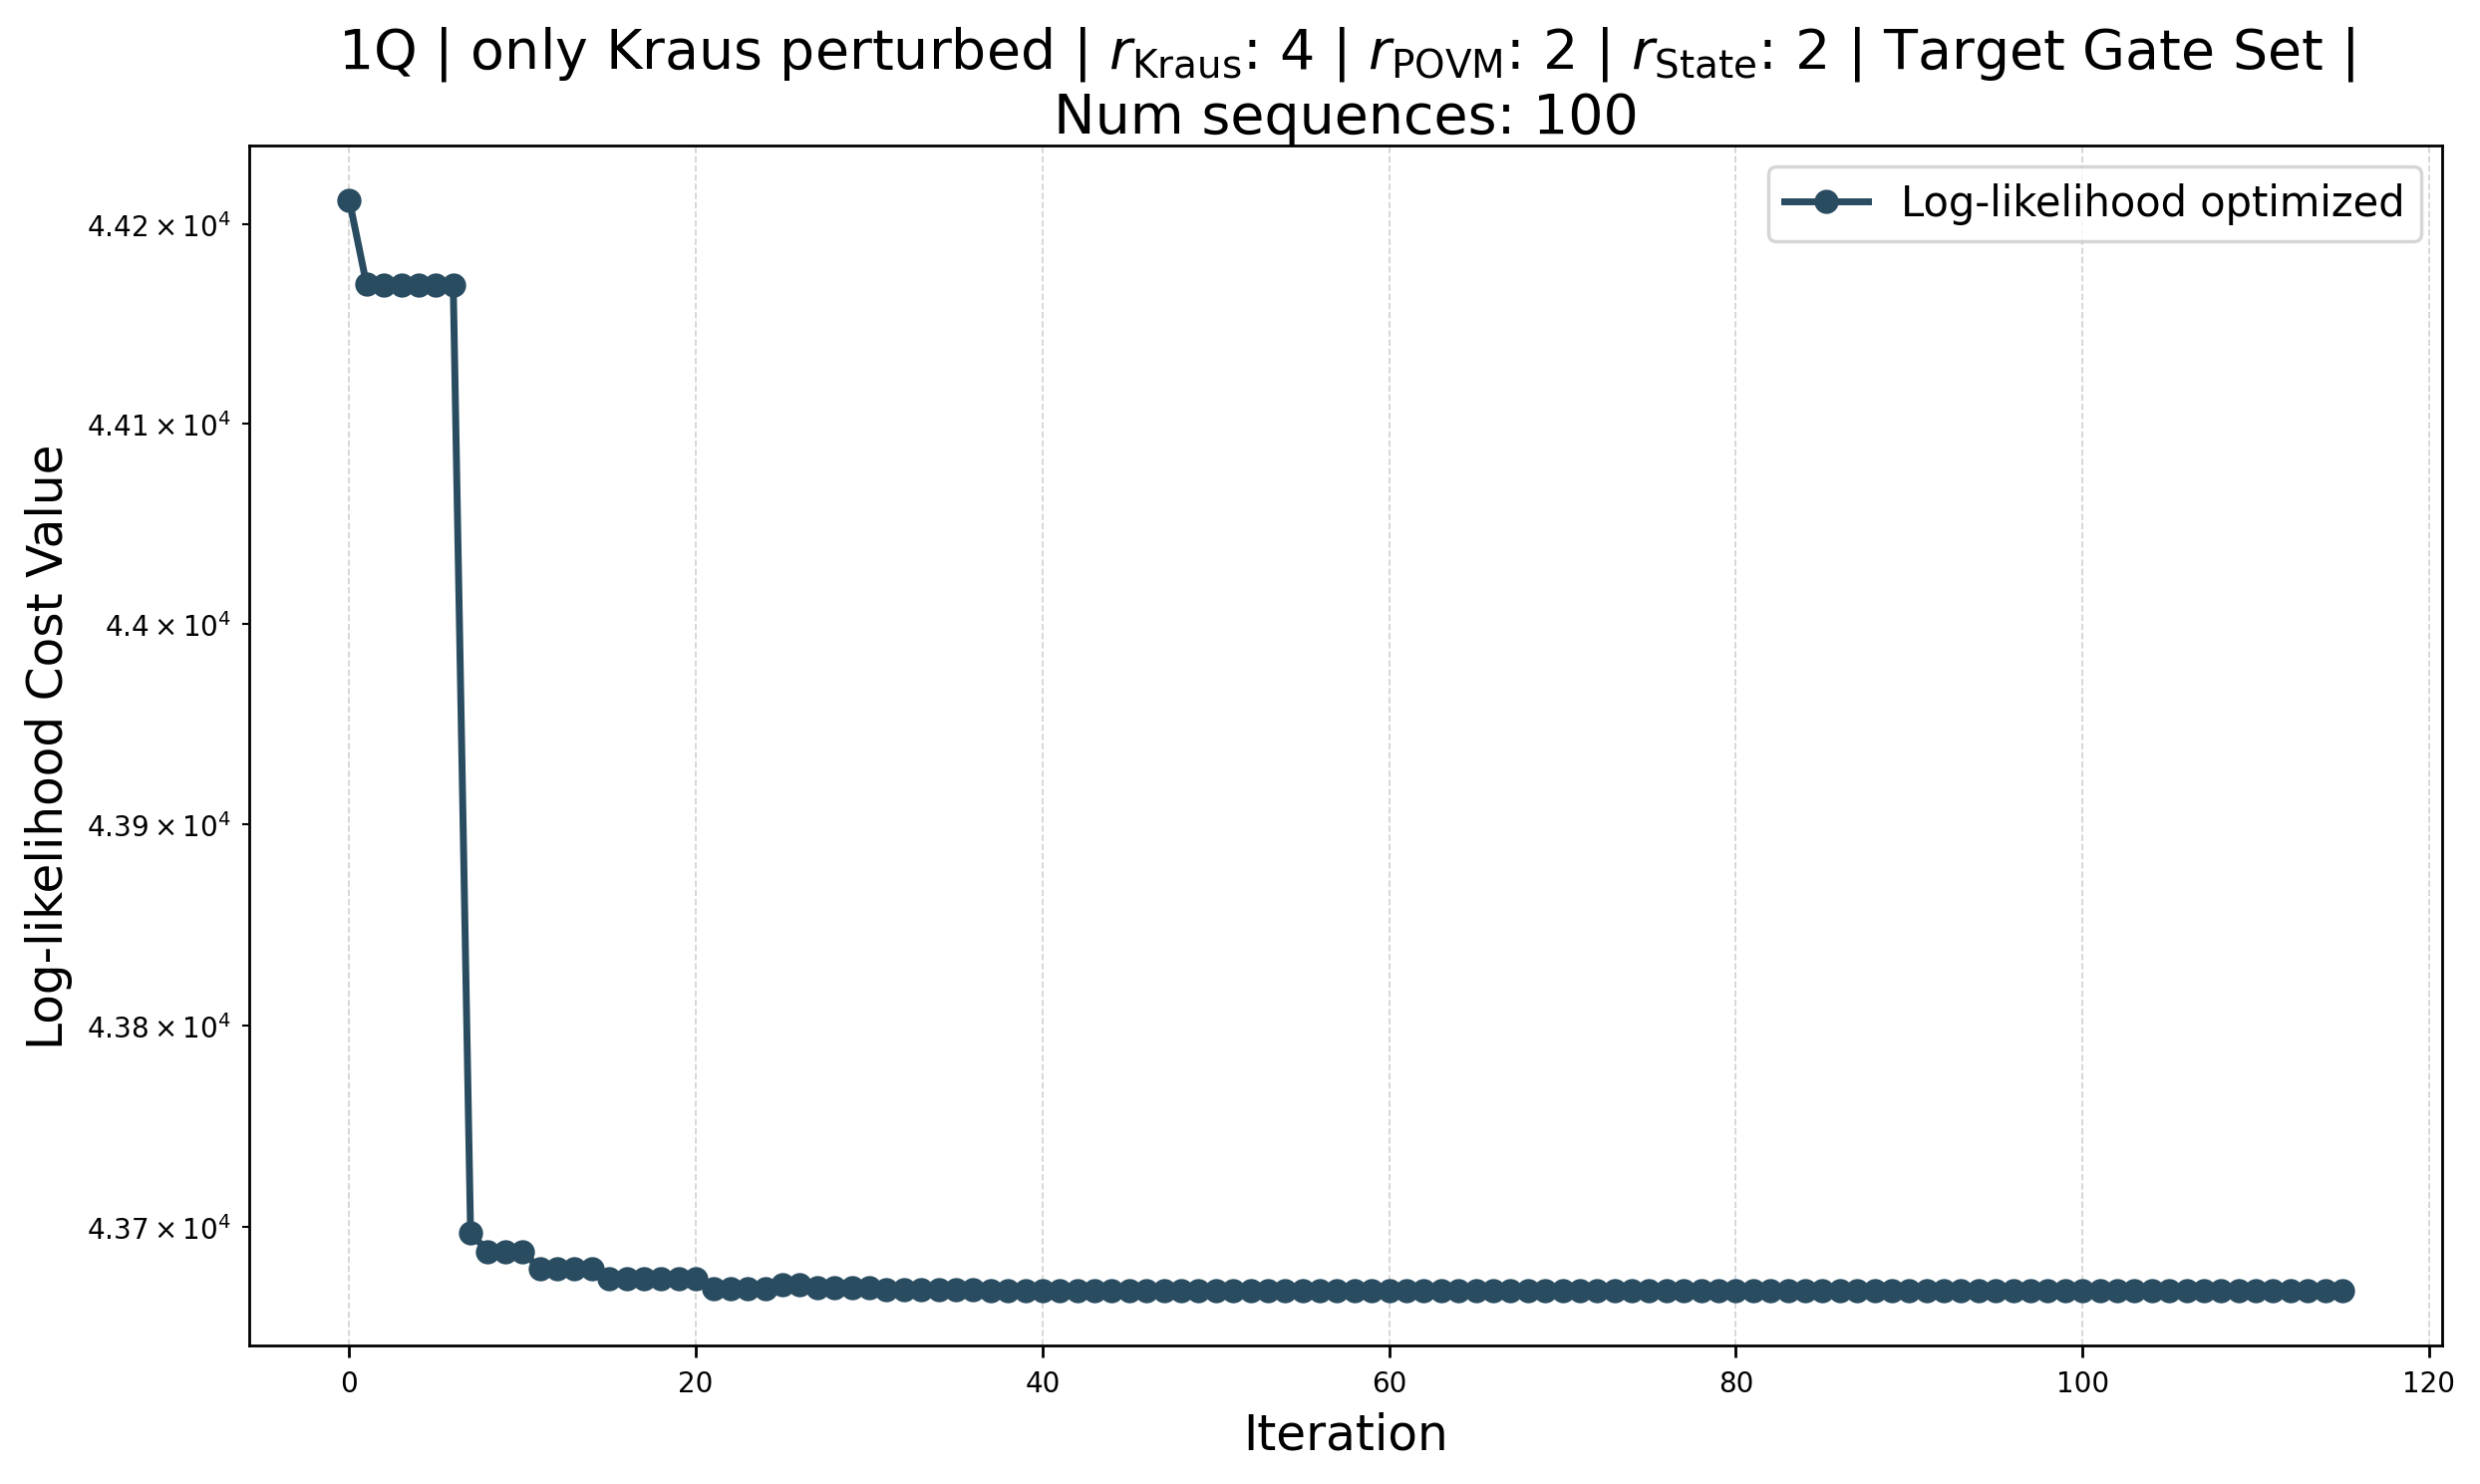

In [31]:
cost_fns = [optimization_results_100_seq_exact_log_likelihood["cost_fn_history"]]
title_cost_fn_vs_shots = rf"{num_qubits}Q | only Kraus perturbed | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Target Gate Set |" + "\n" + f"Num sequences: {num_sequences}"

labels = ["Log-likelihood optimized"]

plot_cost_function(cost_fns, title=title_cost_fn_vs_shots, labels=labels, comparison_yline=None, ylabel="Log-likelihood Cost Value")

# Recreating the MVE vs shots experiments

In [39]:
import numpy as np
shots_list = np.logspace(2,6,5)

In [40]:
optimization_results_list = []
for num_shots in shots_list:
    print(f"Running optimization for num_shots={num_shots}")
    print("--------------------------------")
    optimization_result_i = run_optimization_workflow(
        num_sequences=100,
        num_shots=num_shots,
        init_operators=init_operators,
        operators_psd_true=target_psd_operators,
        target_superops=true_superops,
        use_exact_probabilities=False,
        optimization_options=optimization_options,
        warmup_run=False,        
        use_log_likelihood=True,
        optimization_verbose=False, # we trust it by now for 1Q.
    )
    print(f"Finished optimization for num_shots={num_shots}")
    print("--------------------------------")
    optimization_results_list.append(optimization_result_i)

Running optimization for num_shots=100.0
--------------------------------
Using log-likelihood for the cost function optimization 🧮
🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-19]: TrustRegionOptions
povm: Schedule:
  [0-19]: TrustRegionOptions
state: Schedule:
  [0-19]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-13 
+ Gradient(s) Norm(s) 📐
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 4 the new count changed to: 3
at iteration 10 the new count changed to: 4
at iteration 16 the new count changed to: 5
at iteration 22 the new count changed to: 6
at iteration 29 the new count changed to: 7
at iteration 36 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iterati

In [42]:
gst_superops_list = [res["superops_gauged"] for res in optimization_results_list]
num_shots_samples = 10000
num_random_runs = 10

seq_lengths = [8, 16, 32, 64]

mve_avg_std_vs_length = {}

for length in seq_lengths:
    print(f"⭐️ Computing MVE for sequence length: {length}")
    mve_avg_std_vs_length[length] = mve_avg_and_std_from_list_of_superops(num_runs=num_random_runs, true_superops=true_superops, gst_superops=gst_superops_list, length=length, samples=num_shots_samples)

⭐️ Computing MVE for sequence length: 8
Processing superop no.: 0
Processing superop no.: 1
Processing superop no.: 2
Processing superop no.: 3
Processing superop no.: 4
⭐️ Computing MVE for sequence length: 16
Processing superop no.: 0
Processing superop no.: 1
Processing superop no.: 2
Processing superop no.: 3
Processing superop no.: 4
⭐️ Computing MVE for sequence length: 32
Processing superop no.: 0
Processing superop no.: 1
Processing superop no.: 2
Processing superop no.: 3
Processing superop no.: 4
⭐️ Computing MVE for sequence length: 64
Processing superop no.: 0
Processing superop no.: 1
Processing superop no.: 2
Processing superop no.: 3
Processing superop no.: 4


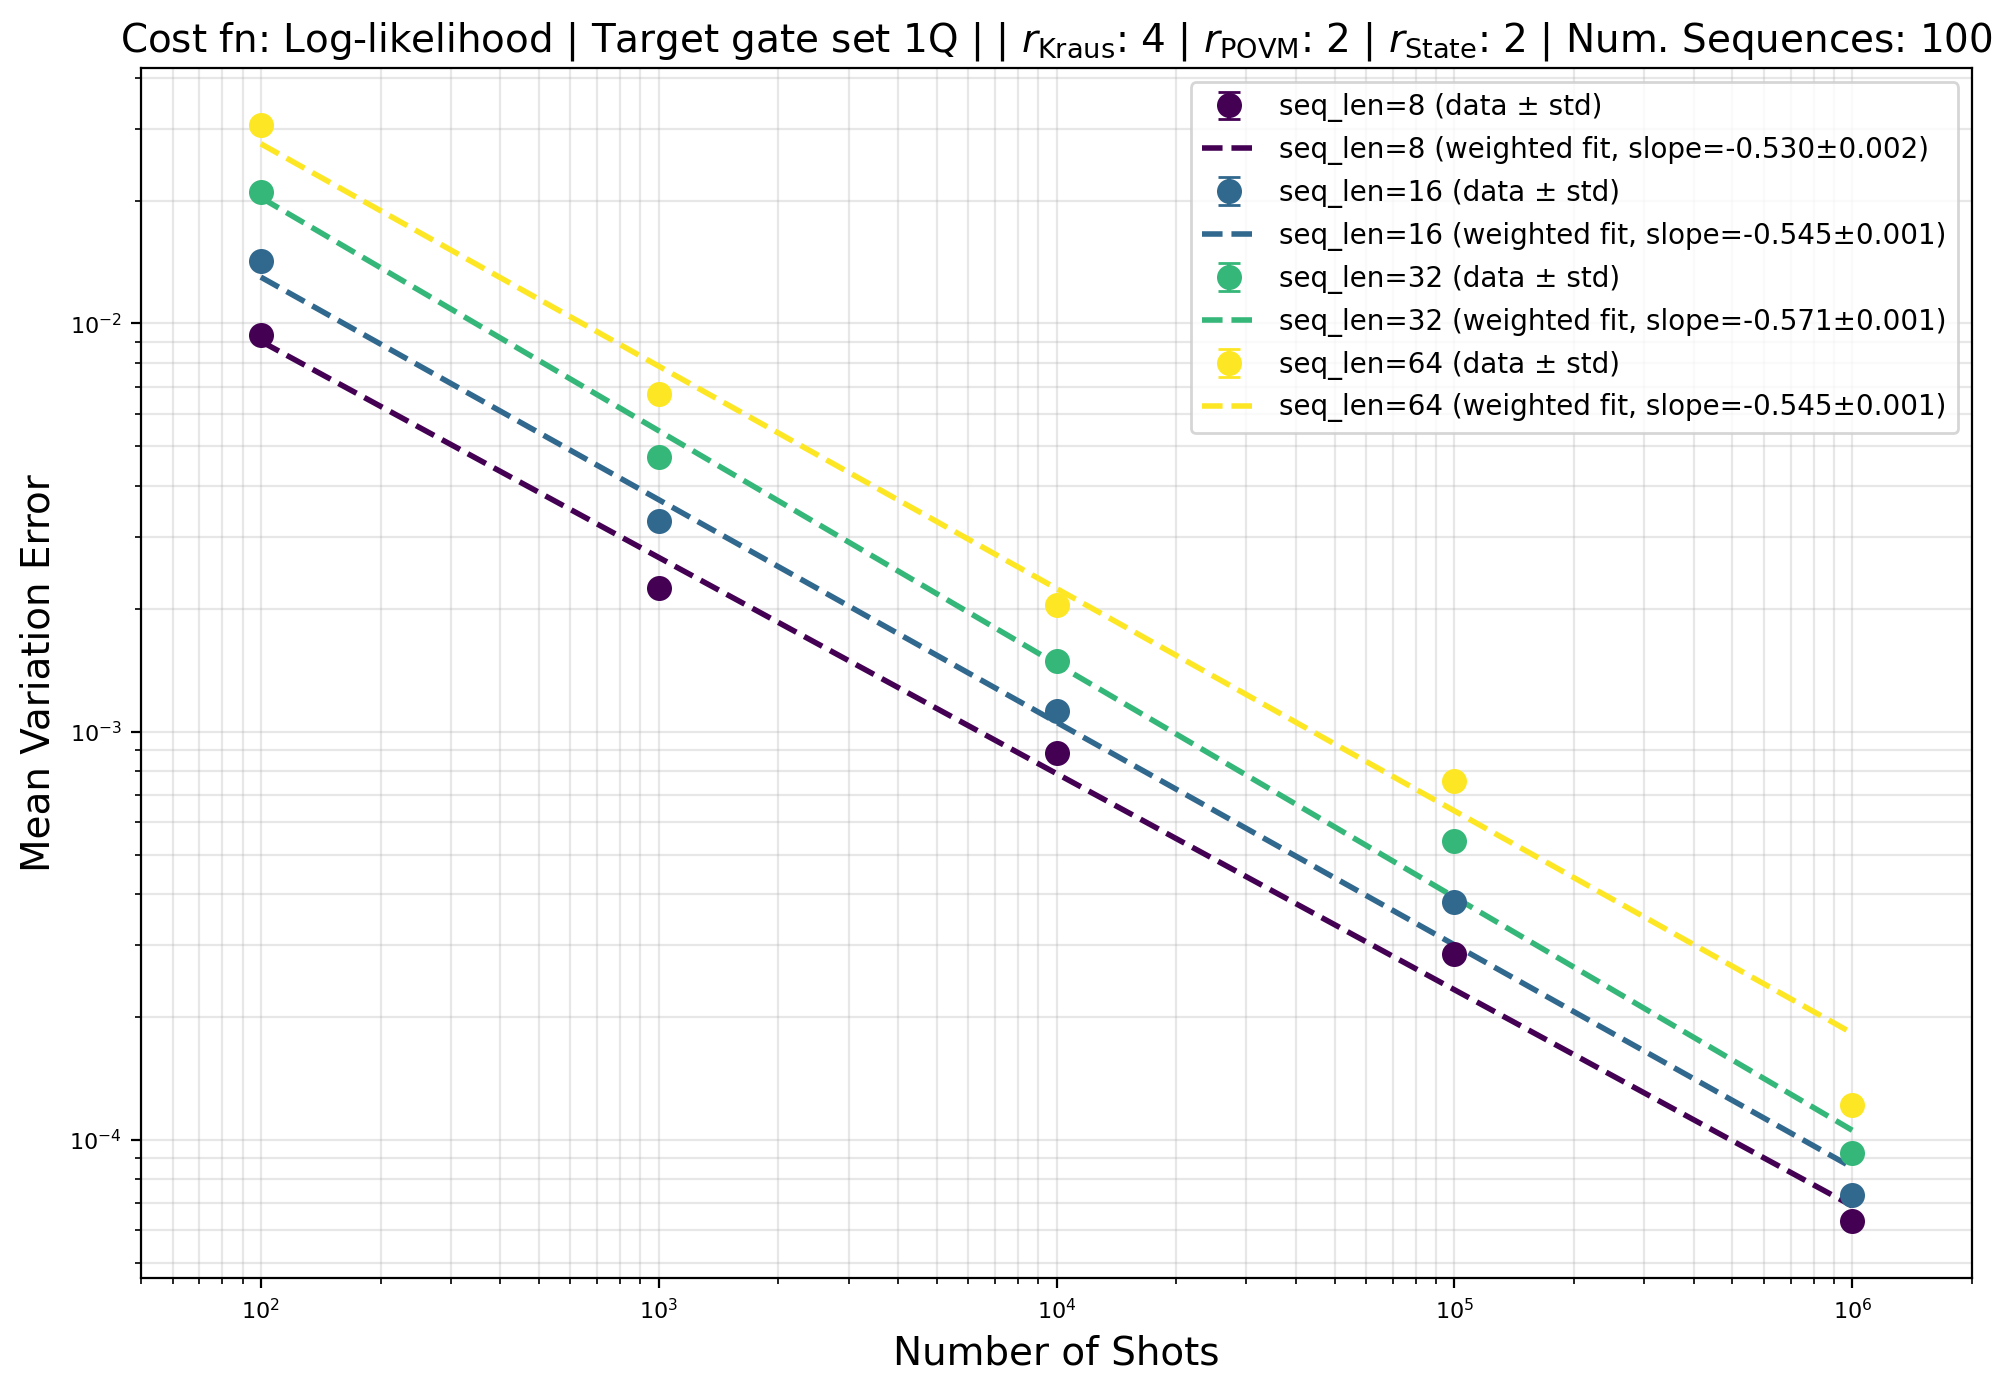

In [50]:
title = rf'Cost fn: Log-likelihood | Target gate set {num_qubits}Q | | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Num. Sequences: 100'

fig, parameters_dict = plot_mve_multiple_seq_lengths_with_error_bars(mve_dict=mve_avg_std_vs_length, shots_list=shots_list, title=title)

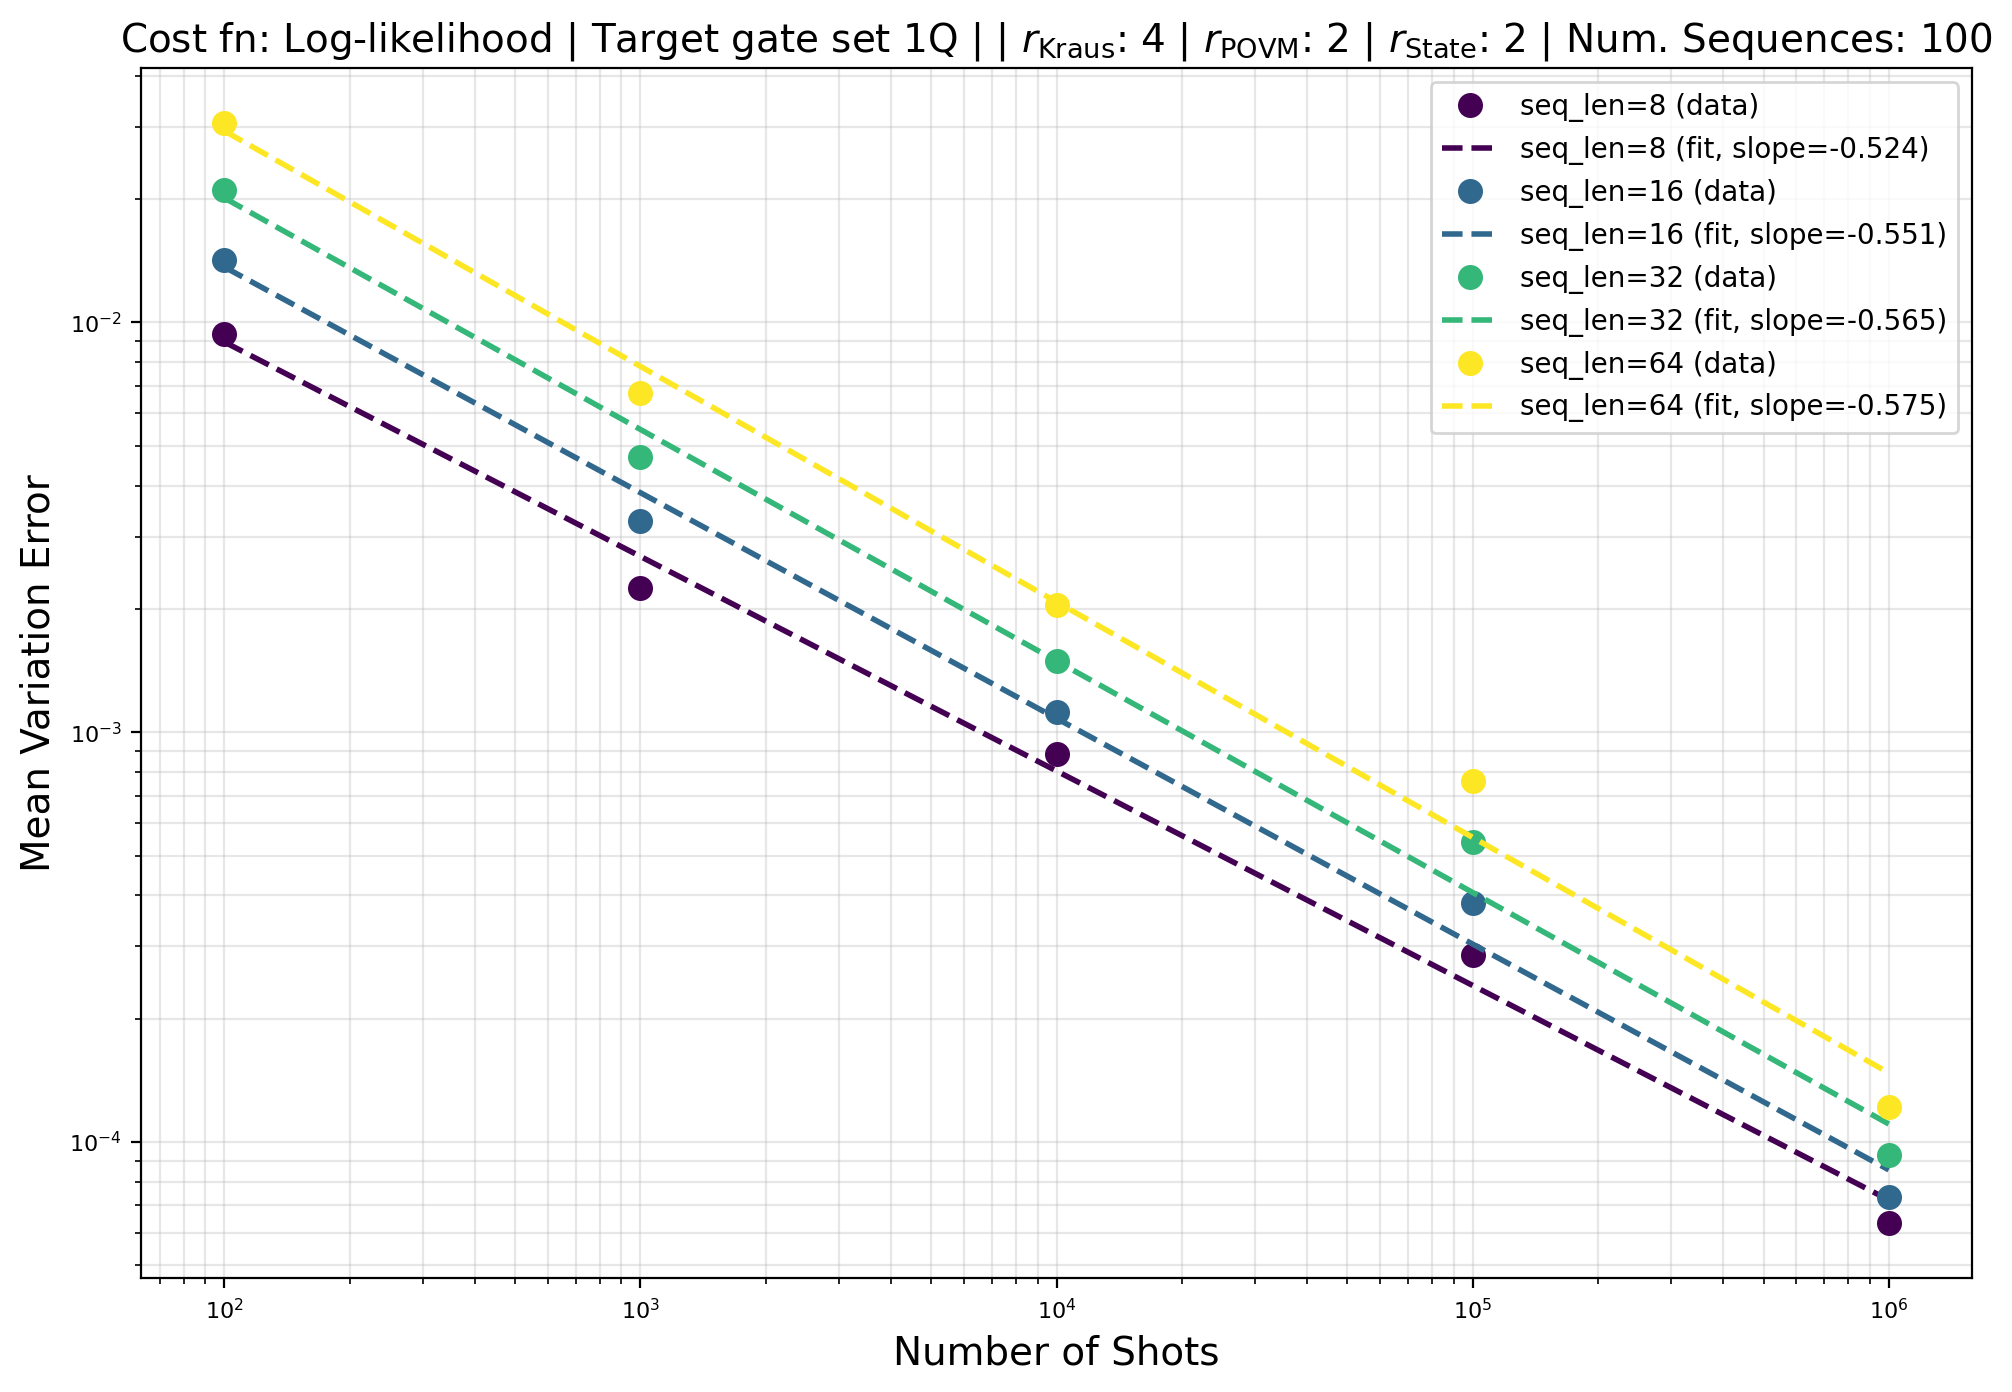

In [51]:
fig_2, parameters_dict_2 = plot_mve_multiple_seq_lengths(mve_dict=mve_avg_std_vs_length, shots_list=shots_list, title=title)

In [78]:
cost_fn_vs_shots = [res["cost_fn_history"] for res in optimization_results_list]

cost_fn_vs_shots_rescaled = [np.array(cost_fn) / shots for cost_fn, shots in zip(cost_fn_vs_shots, shots_list)]

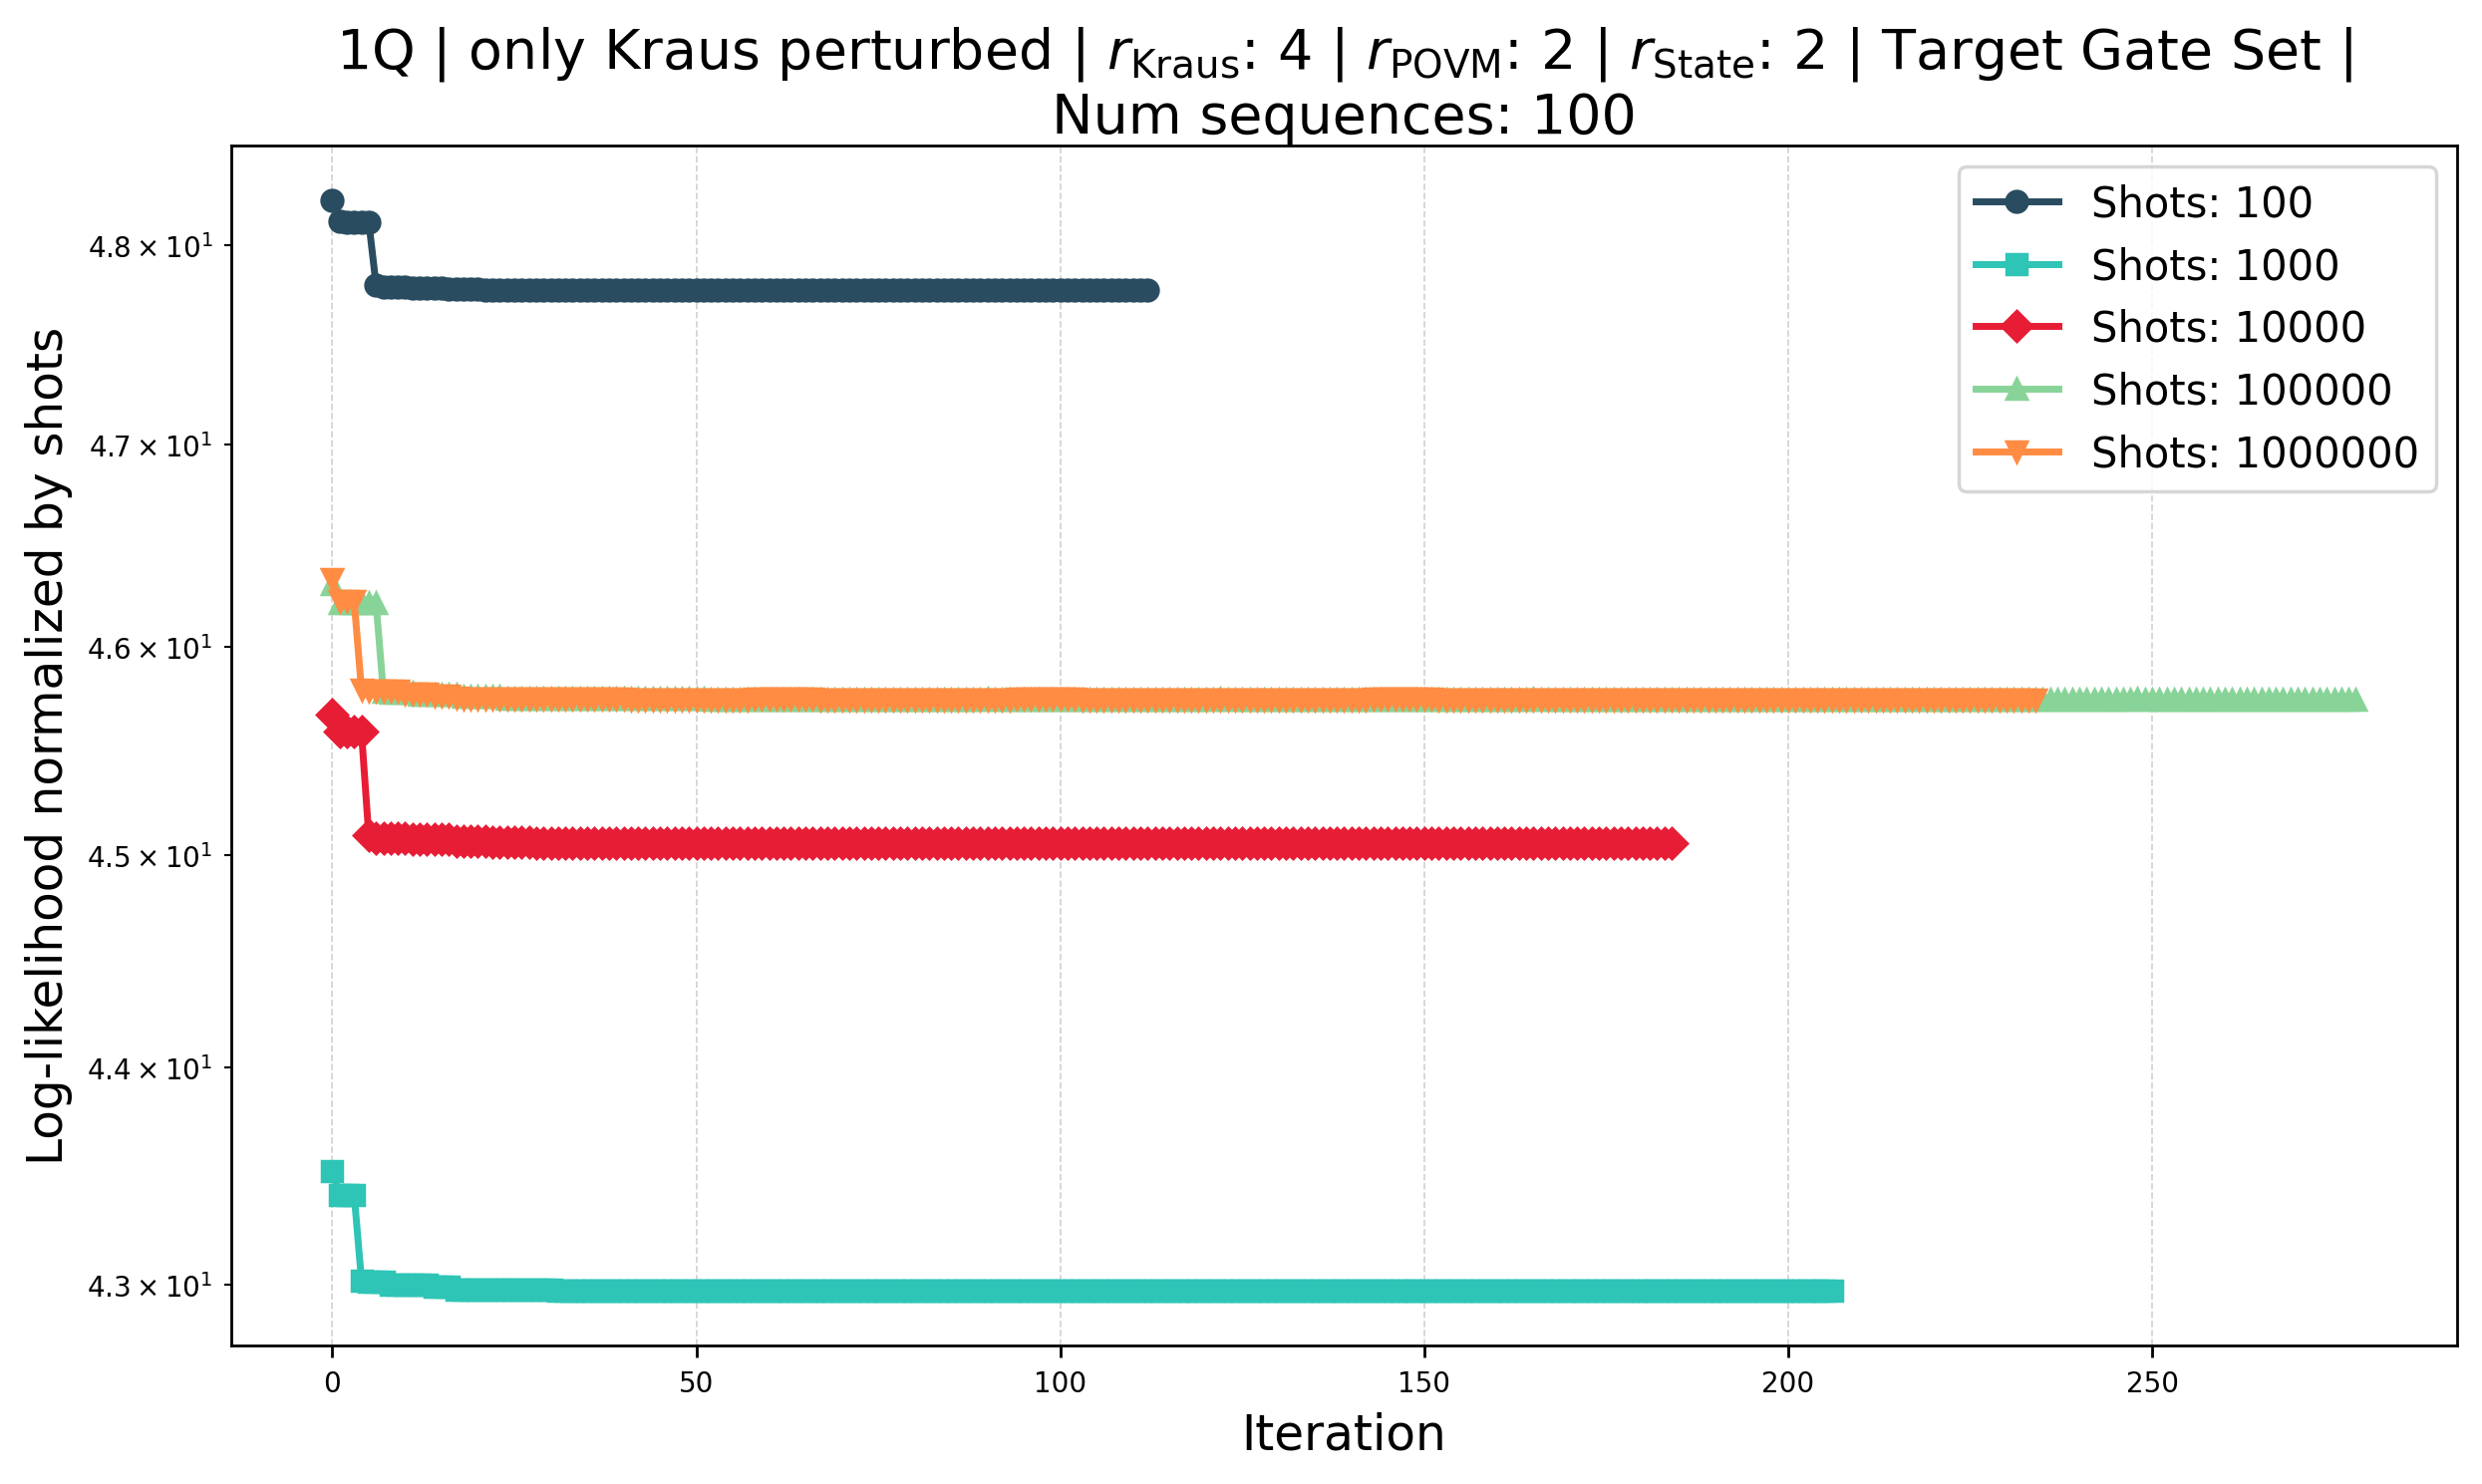

In [97]:
title_cost_fn_vs_shots = rf"{num_qubits}Q | only Kraus perturbed | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Target Gate Set |" + "\n" + f"Num sequences: {num_sequences}"

labels_cst_fn_vs_shots = [f"Shots: {int(num_shots)}" for num_shots in shots_list]

ylabel_cost_fn = "Log-likelihood normalized by shots"

plot_cost_function(cost_fn_vs_shots_rescaled[:], title=title_cost_fn_vs_shots, labels=labels_cst_fn_vs_shots[:], comparison_yline=None, ylabel=ylabel_cost_fn)

In [88]:
# compute the least squares values for the different shots optimizations.

def compute_least_squares_from_optimization_result(optimization_result, cost_fn_kwargs):
    "Utility function to compute the least squares value from the optimization result."
    optimized_ops = optimization_result["optimized_operators"]
    return cost_function_jax_mps(*optimized_ops.values(), **cost_fn_kwargs)

least_squares_values = [compute_least_squares_from_optimization_result(res, cost_fn_kwargs_jax_exact) for res in optimization_results_list]

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 4 the new count changed to: 3
at iteration 10 the new count changed to: 4
at iteration 16 the new count changed to: 5
at iteration 22 the new count changed to: 6
at iteration 29 the new count changed to: 7
at iteration 36 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iteration 82 the new count changed to: 14
at iteration 91 the new count changed to: 15


In [96]:
for num_shots, least_squares in zip(shots_list, least_squares_values):
    print(f"Num shots: {num_shots:.1e} | Least squares value: {least_squares:.4e}")

Num shots: 1.0e+02 | Least squares value: 2.0896e-04
Num shots: 1.0e+03 | Least squares value: 8.0833e-06
Num shots: 1.0e+04 | Least squares value: 1.7940e-06
Num shots: 1.0e+05 | Least squares value: 1.4161e-07
Num shots: 1.0e+06 | Least squares value: 7.3985e-09
